In [1]:
# Mount Drive (force refresh tokens if needed)
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Project dir (matches your screenshot)
PROJECT_DIR = "/content/drive/MyDrive/colab_training"
%cd $PROJECT_DIR

# Make sure Python can import this folder
import sys, os, glob, re, shutil, zipfile, pathlib
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

!ls -la


Mounted at /content/drive
/content/drive/MyDrive/colab_training
total 173
-rw------- 1 root root  3236 Nov  1 05:38 COLAB_SETUP.md
drwx------ 2 root root  4096 Nov  4 04:46 dataset
-rw------- 1 root root 78030 Nov  3 16:55 DenseNet_Colab_Training.ipynb
-rw------- 1 root root 13713 Oct 31 18:18 densenet_occlusion.py
-rw------- 1 root root 16394 Oct 31 18:19 densenet_plot.py
-rw------- 1 root root 10170 Nov  1 05:46 densenet_saliency.py
-rw------- 1 root root  4920 Nov  2 18:43 densenet_tomato_model.py
-rw------- 1 root root  7744 Nov  4 00:37 densenet_trainer_logged.py
-rw------- 1 root root  8554 Oct 31 20:51 densenet_trainer.py
drwx------ 2 root root  4096 Nov  4 07:20 _extract_tmp
-rw------- 1 root root    95 Nov  1 05:46 __init__.py
drwx------ 2 root root  4096 Nov  4 00:48 __pycache__
-rw------- 1 root root  5753 Oct 31 18:16 torchvis_util.py
drwx------ 2 root root  4096 Nov  4 00:48 trained_models
-rw------- 1 root root  4218 Nov  4 00:37 training_metrics.py
drwx------ 2 root root

In [2]:
# Find your dataset zip. We check root and project folder, case-insensitive (Dataset.zip / dataset.zip).
candidates = []
for base in ["/content/drive/MyDrive", PROJECT_DIR]:
    candidates += glob.glob(os.path.join(base, "*ataset*.zip"))

if not candidates:
    raise FileNotFoundError(
        "Couldn't find Dataset.zip/dataset.zip in My Drive or colab_training. "
        "Put it in either location and re-run."
    )

ZIP_PATH = sorted(candidates, key=len)[0]
print("📦 Using ZIP:", ZIP_PATH)

# Target dirs
DATASET_DIR = os.path.join(PROJECT_DIR, "dataset")
TDIR = os.path.join(DATASET_DIR, "tomato_disease")
TMP = os.path.join(PROJECT_DIR, "_extract_tmp")

# Create dirs
os.makedirs(DATASET_DIR, exist_ok=True)
os.makedirs(TMP, exist_ok=True)

# Skip if already in place
if os.path.isdir(os.path.join(TDIR, "train")) and os.path.isdir(os.path.join(TDIR, "val")):
    print("✅ tomato_disease/train & val already exist. Skipping extraction.")
else:
    # Clean previous tmp
    if os.path.exists(TMP):
        shutil.rmtree(TMP)
        os.makedirs(TMP, exist_ok=True)

    # Extract ZIP (safe for large trees)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(TMP)
    print("✅ Extracted to temp:", TMP)

    # Find the folder that has both 'train' and 'val'
    def find_root_has_train_val(root):
        for cur, dirs, files in os.walk(root):
            dset = set([d.lower() for d in dirs])
            if "train" in dset and "val" in dset:
                return cur
        return None

    found = find_root_has_train_val(TMP)
    if not found:
        raise RuntimeError("Could not locate a folder containing both 'train' and 'val' inside the zip.")

    print("📁 Found dataset root:", found)

    # Ensure target clean
    if os.path.exists(TDIR):
        shutil.rmtree(TDIR)
    os.makedirs(TDIR, exist_ok=True)

    # Move train/val into the final location
    for sub in ("train", "val"):
        src = os.path.join(found, sub)
        dst = os.path.join(TDIR, sub)
        if not os.path.exists(src):
            raise RuntimeError(f"Missing '{sub}' in {found}")
        shutil.move(src, dst)
        print(f"➡️  Moved {src} -> {dst}")

    # Optional: keep classes tidy and remove tmp
    shutil.rmtree(TMP, ignore_errors=True)
    print("🧹 Cleaned temp.")


📦 Using ZIP: /content/drive/MyDrive/Dataset.zip
✅ tomato_disease/train & val already exist. Skipping extraction.


In [3]:
import os, itertools

TDIR = "/content/drive/MyDrive/colab_training/dataset/tomato_disease"
ok = os.path.isdir(TDIR) and os.path.isdir(os.path.join(TDIR,"train")) and os.path.isdir(os.path.join(TDIR,"val"))
print("Structure OK:", ok)

if ok:
    print("Classes (train):", sorted(next(os.walk(os.path.join(TDIR,"train")))[1])[:10], "…")
    print("Classes (val):",   sorted(next(os.walk(os.path.join(TDIR,"val")))[1])[:10], "…")

# Quick file count
def count_images(p):
    cnt = 0
    for cur, _, files in os.walk(p):
        cnt += sum(1 for f in files if f.lower().endswith(('.png','.jpg','.jpeg','.bmp','.webp')))
    return cnt

if ok:
    print("🖼️  #train images:", count_images(os.path.join(TDIR,'train')))
    print("🖼️  #val images:",   count_images(os.path.join(TDIR,'val')))



Structure OK: True
Classes (train): ['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy'] …
Classes (val): ['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy'] …
🖼️  #train images: 11202
🖼️  #val images: 1607


In [4]:
!pip install torch==2.3.1 torchvision==0.18.1 --quiet



In [5]:
# Uses your existing files in colab_training
from densenet_trainer_logged import DenseNetTrainerLogged

trainer = DenseNetTrainerLogged(
    data_dir="dataset/tomato_disease",   # this matches where we placed it
    save_dir="trained_models",
    plots_dir="training_plots"
)
paths = trainer.run()
paths

🍅 DenseNet169 Tomato Trainer (Logged)
📁 Dataset: dataset/tomato_disease
💾 Save dir: trained_models
🖼️  Plots dir: training_plots
🔧 Device: cuda
📂 Loading dataset...
🧮 Classes: 10 -> ['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
📊 Train images: 11202, Val images: 1607


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet169_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet169_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Created DenseNet169 model with 10 output classes.
📅 Epoch 1/25


/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


   🧪 Train Loss: 0.6254 | Train Acc: 81.07%
   🔍 Val   Loss: 0.1854 | Val   Acc: 94.28%
   📉 LR: 0.001000
📅 Epoch 2/25
   🧪 Train Loss: 0.1762 | Train Acc: 94.51%
   🔍 Val   Loss: 0.0990 | Val   Acc: 96.70%
   📉 LR: 0.001000
📅 Epoch 3/25
   🧪 Train Loss: 0.1242 | Train Acc: 96.15%
   🔍 Val   Loss: 0.0506 | Val   Acc: 98.63%
   📉 LR: 0.001000
📅 Epoch 4/25
   🧪 Train Loss: 0.0972 | Train Acc: 96.86%
   🔍 Val   Loss: 0.0624 | Val   Acc: 97.95%
   📉 LR: 0.001000
📅 Epoch 5/25
   🧪 Train Loss: 0.0934 | Train Acc: 96.84%
   🔍 Val   Loss: 0.0391 | Val   Acc: 99.07%
   📉 LR: 0.001000
📅 Epoch 6/25
   🧪 Train Loss: 0.0721 | Train Acc: 97.74%
   🔍 Val   Loss: 0.0514 | Val   Acc: 98.32%
   📉 LR: 0.001000
📅 Epoch 7/25
   🧪 Train Loss: 0.0733 | Train Acc: 97.63%
   🔍 Val   Loss: 0.0386 | Val   Acc: 99.13%
   📉 LR: 0.001000
📅 Epoch 8/25
   🧪 Train Loss: 0.0731 | Train Acc: 97.68%
   🔍 Val   Loss: 0.0366 | Val   Acc: 99.00%
   📉 LR: 0.001000
📅 Epoch 9/25
   🧪 Train Loss: 0.0558 | Train Acc: 98.24%
   🔍

{'weights': 'trained_models/densenet169_tomato_acc99.63.pth',
 'csv': 'trained_models/training_stats.csv',
 'json': 'trained_models/training_stats.json',
 'plots_dir': 'training_plots'}

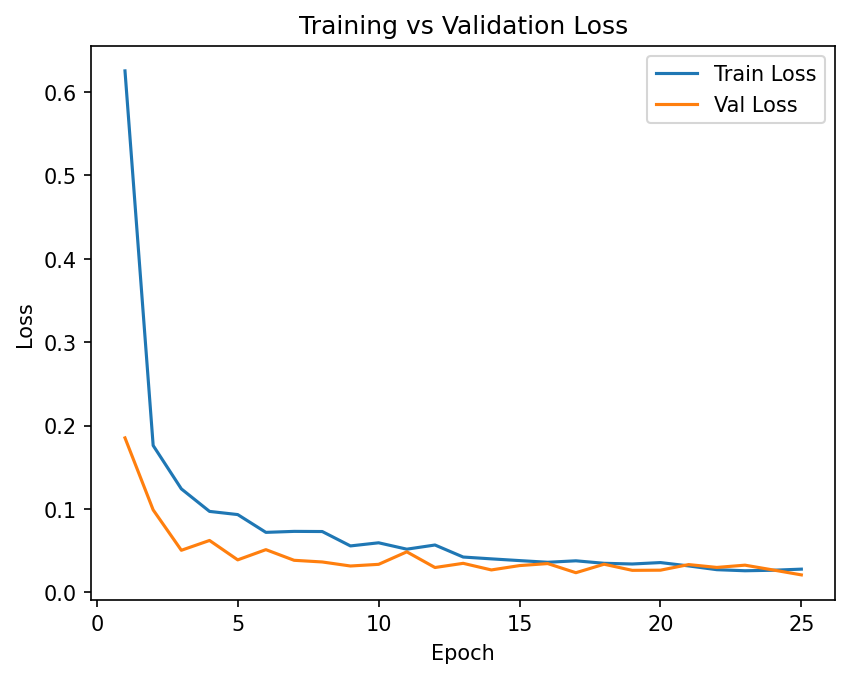

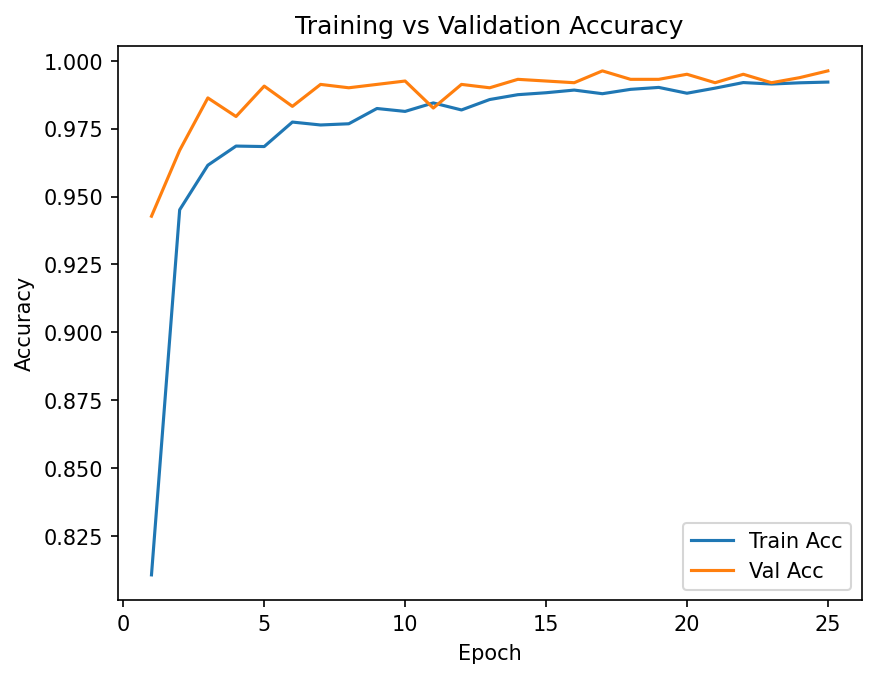

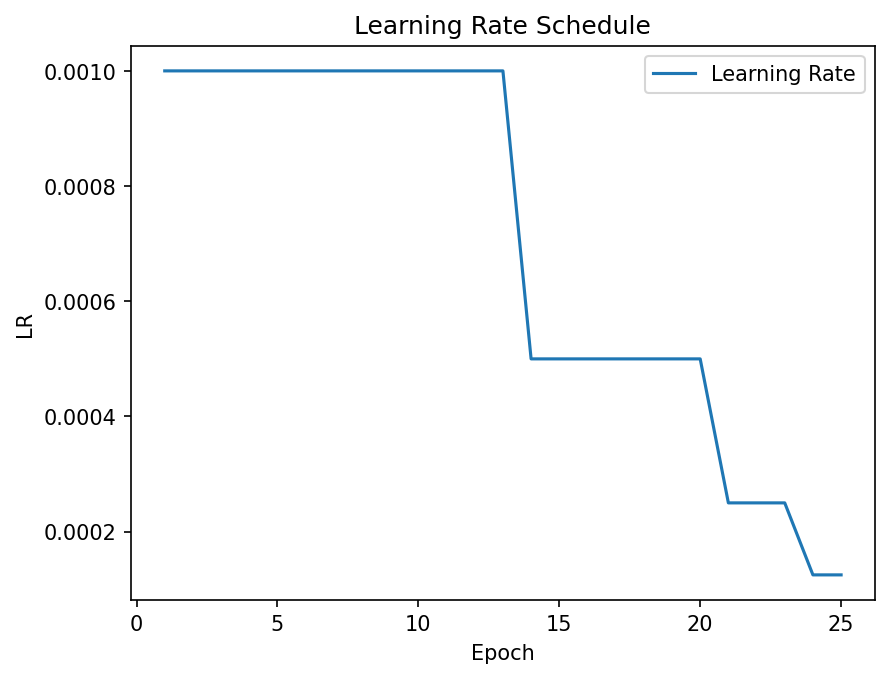

,epoch,train_loss,val_loss,train_acc,val_acc,lr
20,21,0.031846,0.033455,0.989913,0.991910,0.000250
21,22,0.027330,0.030039,0.991966,0.995022,0.000250
22,23,0.026044,0.032744,0.991430,0.991910,0.000250
23,24,0.026663,0.026962,0.991876,0.993777,0.000125
24,25,0.027982,0.021095,0.992144,0.996266,0.000125


In [6]:
from IPython.display import Image, display
import os, pandas as pd

for f in ("densenet169_loss.png","densenet169_accuracy.png","densenet169_lr.png"):
    fp = os.path.join("training_plots", f)
    if os.path.exists(fp):
        display(Image(filename=fp))

df = pd.read_csv("trained_models/training_stats.csv")
df.tail()


In [7]:
import torch, glob, os
from densenet_tomato_model import DenseNetTomatoClassifier
from torchvision import datasets, transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ckpt = sorted(glob.glob("trained_models/*.pth"), key=os.path.getmtime)[-1]
print("Loading:", ckpt)

model = DenseNetTomatoClassifier().create_model().to(device)
model.load_state_dict(torch.load(ckpt, map_location=device))
model.eval()

val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
val_dir = "/content/drive/MyDrive/colab_training/dataset/tomato_disease/val"
val_set = datasets.ImageFolder(val_dir, val_tf)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=32, shuffle=False, num_workers=2)

correct = total = 0
with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)

print(f"Validation accuracy: {100.0*correct/total:.2f}%  ({correct}/{total})")


Loading: trained_models/densenet169_tomato_acc99.63.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet169_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet169_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Created DenseNet169 model with 10 output classes.
Validation accuracy: 99.63%  (1601/1607)
